# Project Delay Random Forest Models With Approved Keyword Features

This notebook reruns the project-delay random forest analysis using the newer restricted feature dataset built from the approved keyword set.

It evaluates three target formulations:

- Continuous regression: predict `PercentDelayed`.
- Binary classification: predict whether `PercentDelayed > 0`.
- Three-bin classification:
  - Bin 1: before/on time, `PercentDelayed <= 0`
  - Bin 2: mildly late, `0 < PercentDelayed <= 25`
  - Bin 3: moderately/severely late, `PercentDelayed > 25`

It also compares two feature universes:

- **Total usable:** all numeric non-leakage features in the approved dataset, excluding IDs, customer name, raw text, `PercentDelayed`, and `TARGET*` payment-history fields.
- **Before only:** fields marked beginning-available or conditionally beginning-available in the non-keyword field dictionary, plus approved keyword features, excluding IDs, customer name, raw text, `PROJECTSTATUS`, `PercentDelayed`, and `TARGET*` fields.

Finally, it reviews several train/test split strategies:

- Reproducible hash split.
- Time split where training projects are older than test projects.
- Leave-one-customer-out tests.
- Conservative UDOT-only historical training: train on the oldest 80% of UDOT projects, then evaluate on newer UDOT projects and other customers.

In [1]:
from pathlib import Path
import hashlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
)
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, KFold, StratifiedKFold

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 220)

DATA_PATH = Path('custpaydetails_project_feature_table_with_approved_keywords_2026-06-11.csv')
FIELD_DICT_PATH = Path('project_feature_non_keyword_field_dictionary_2026-06-10.csv')
RANDOM_STATE = 42
N_ESTIMATORS = 250
MIN_SAMPLES_LEAF = 5

## Load Data

The approved-keyword dataset keeps all non-keyword fields and only those keyword feature columns whose terms passed the usage screen and manual semantic review.

In [2]:
df = pd.read_csv(DATA_PATH, low_memory=False)
field_dict = pd.read_csv(FIELD_DICT_PATH)

print(f'Rows: {len(df):,}')
print(f'Columns: {df.shape[1]:,}')
print(f'Non-keyword dictionary fields: {len(field_dict):,}')

keyword_prefixes = ('PROJ_KW_', 'CONTRACT_KW_', 'ITEM_KW_')
keyword_cols = [c for c in df.columns if c.startswith(keyword_prefixes)]
non_keyword_cols = [c for c in df.columns if not c.startswith(keyword_prefixes)]
print(f'Approved keyword feature columns: {len(keyword_cols):,}')
print(f'Non-keyword columns present: {len(non_keyword_cols):,}')

print('\nCustomer rows:')
display(df['CUSTOMERNAME'].value_counts(dropna=False).to_frame('Rows'))

Rows: 5,762
Columns: 4,216
Non-keyword dictionary fields: 75
Approved keyword feature columns: 4,141
Non-keyword columns present: 75

Customer rows:


,Rows
CUSTOMERNAME,
Lincoln,3559
UDOT,1578
CCD,239
CLV,199
Adams,140
Amtrak,47


## Target Population And Labels

Rows without `PercentDelayed` cannot be used for supervised delay modeling. They remain important for production scoring later, but they do not have a historical label for training/testing.

Labeled rows: 3,469 (60.2% of full approved dataset)

PercentDelayed summary:


,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
PERCENTDELAYED,3469.0,103.367586,406.53852,-99.716629,-91.788008,-90.68323,-89.43662,-80.263158,16.22807,168.115942,360.0,538.75916,1162.824859,12800.0



Binary label distribution:


,Rows
DelayedBinary,
not delayed,1658
delayed,1811



Three-bin label distribution:


,Rows
DelayBinLabel,
before/on time,1658
mildly late,120
moderate/severe late,1691


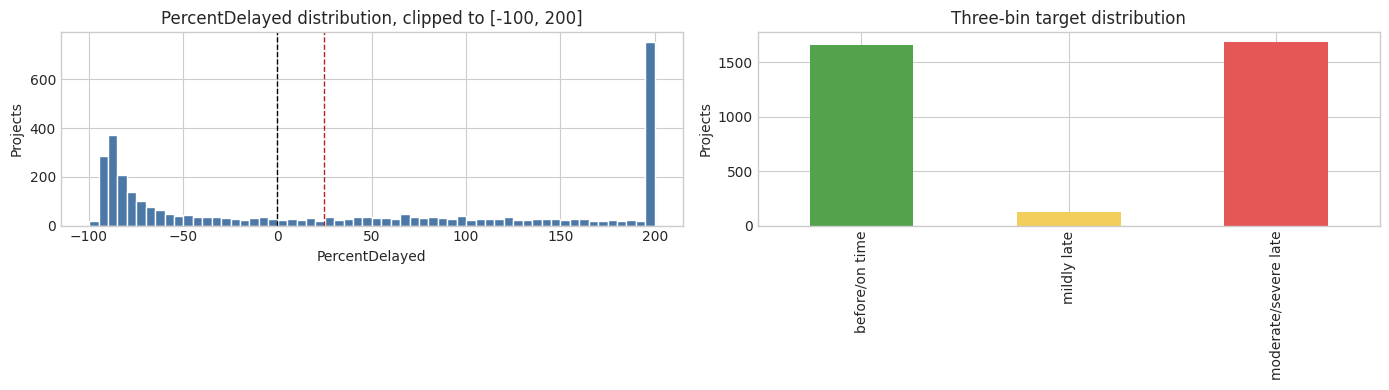

In [3]:
model_df = df[df['PERCENTDELAYED'].notna()].copy()
model_df['DelayedBinary'] = (model_df['PERCENTDELAYED'] > 0).astype(int)
model_df['DelayBin'] = pd.cut(
    model_df['PERCENTDELAYED'],
    bins=[-np.inf, 0, 25, np.inf],
    labels=[0, 1, 2],
    right=True,
).astype(int)
model_df['DelayBinLabel'] = model_df['DelayBin'].map({0: 'before/on time', 1: 'mildly late', 2: 'moderate/severe late'})

print(f'Labeled rows: {len(model_df):,} ({len(model_df)/len(df):.1%} of full approved dataset)')
print('\nPercentDelayed summary:')
display(model_df['PERCENTDELAYED'].describe(percentiles=[.01,.05,.10,.25,.50,.75,.90,.95,.99]).to_frame().T)
print('\nBinary label distribution:')
display(model_df['DelayedBinary'].value_counts().sort_index().rename(index={0:'not delayed',1:'delayed'}).to_frame('Rows'))
print('\nThree-bin label distribution:')
display(model_df['DelayBinLabel'].value_counts().reindex(['before/on time','mildly late','moderate/severe late']).to_frame('Rows'))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(model_df['PERCENTDELAYED'].clip(-100, 200), bins=60, color='#4c78a8', edgecolor='white')
axes[0].axvline(0, color='black', linestyle='--', linewidth=1)
axes[0].axvline(25, color='firebrick', linestyle='--', linewidth=1)
axes[0].set_title('PercentDelayed distribution, clipped to [-100, 200]')
axes[0].set_xlabel('PercentDelayed')
axes[0].set_ylabel('Projects')
model_df['DelayBinLabel'].value_counts().reindex(['before/on time','mildly late','moderate/severe late']).plot(kind='bar', ax=axes[1], color=['#54a24b','#f2cf5b','#e45756'])
axes[1].set_title('Three-bin target distribution')
axes[1].set_xlabel('')
axes[1].set_ylabel('Projects')
plt.tight_layout()
plt.show()

## Feature Set Definitions

The models intentionally avoid direct leakage fields. The `TARGET*` fields and `PERCENTDELAYED` are retrospective outcomes or target components. Identifiers and raw text are excluded from direct modeling. `CUSTOMERNAME` is excluded from predictors to keep the model customer-agnostic, but it is retained for split analysis.

In [4]:
field_group = dict(zip(field_dict['FieldName'], field_dict['FieldGroup']))
beginning_available = dict(zip(field_dict['FieldName'], field_dict['BeginningAvailable']))

target_cols = {'PERCENTDELAYED', 'DelayedBinary', 'DelayBin', 'DelayBinLabel'}
target_component_cols = set(field_dict.loc[field_dict['FieldGroup'].eq('target/post-payment'), 'FieldName'])
target_component_cols |= {c for c in df.columns if c.startswith('TARGET')}
identifier_or_text_cols = {
    'RECORD_ID', 'PROJECTID', 'PROJECTNAME', 'PROJECTDESCRIPTION', 'PROJECTCODE',
    'CUSTOMERNAME', 'PROJECTSTATUS'
}
# PROJECTSTATUS is excluded from both default feature sets because this extract-time status is not safely reconstructable at project start.
leakage_or_nonpredictor_cols = target_cols | target_component_cols | identifier_or_text_cols

numeric_cols = [c for c in model_df.columns if pd.api.types.is_numeric_dtype(model_df[c])]

total_feature_cols = [
    c for c in numeric_cols
    if c not in leakage_or_nonpredictor_cols
]

allowed_beginning_values = {
    'Yes',
    'Yes, if planned duration valid',
    'Yes, if planned end date exists',
    'Yes, if closure dates entered',
    'Yes, if closure date is entered at setup',
}
before_nonkeyword_cols = [
    c for c in numeric_cols
    if c in beginning_available
    and beginning_available[c] in allowed_beginning_values
    and c not in leakage_or_nonpredictor_cols
]
before_feature_cols = sorted(set(before_nonkeyword_cols) | set(keyword_cols))
before_feature_cols = [c for c in before_feature_cols if c in numeric_cols and c not in leakage_or_nonpredictor_cols]

feature_sets = {
    'total_usable': total_feature_cols,
    'before_only': before_feature_cols,
}

feature_set_summary = pd.DataFrame([
    {
        'FeatureSet': name,
        'FeatureCount': len(cols),
        'KeywordColumns': sum(c.startswith(keyword_prefixes) for c in cols),
        'NonKeywordColumns': sum(not c.startswith(keyword_prefixes) for c in cols),
    }
    for name, cols in feature_sets.items()
])
display(feature_set_summary)

print('Excluded target/component columns present:')
print(sorted([c for c in target_component_cols if c in df.columns])[:50])
print(f'... total target/component columns excluded: {len([c for c in target_component_cols if c in df.columns])}')

,FeatureSet,FeatureCount,KeywordColumns,NonKeywordColumns
0,total_usable,4194,4141,53
1,before_only,4188,4141,47


Excluded target/component columns present:
['PERCENTDELAYED', 'TARGETACTUALDURATIONDAYS', 'TARGETACTUALENDDATE', 'TARGETACTUALSTARTDATE', 'TARGETFIRSTPOSTINGDATE', 'TARGETLASTPOSTINGDATE', 'TARGETPAYMENTSPANDAYS', 'TARGETPLANNEDDURATIONDAYS', 'TARGETPLANNEDENDDATE', 'TARGETPLANNEDSTARTDATE', 'TARGETVALIDPOSTEDDETAILROWS', 'TARGETVALIDPOSTEDPAYDATECOUNT', 'TARGETVALIDPOSTEDPROJECTWORKCOMPLETEDAMOUNT']
... total target/component columns excluded: 13


## Split Strategy Construction

The hash split is useful for stable benchmark comparisons. The time and customer splits are more important for deployment realism:

- **Time split:** train on older planned-start projects and test on newer projects.
- **Leave-one-customer-out:** test whether a model learned transferable signals instead of customer-specific text and workflow patterns.
- **UDOT old-only:** train only on the oldest 80% of UDOT labeled projects, then evaluate on newer UDOT and every other customer. This is deliberately conservative because it tests both temporal drift and cross-customer transfer from a narrow training source.

In [5]:
def stable_hash_fraction(*parts):
    key = '||'.join('' if pd.isna(p) else str(p) for p in parts)
    digest = hashlib.md5(key.encode('utf-8')).hexdigest()
    return int(digest[:12], 16) / float(16**12)

split_df = model_df[['CUSTOMERNAME', 'PROJECTID', 'PROJECTNAME', 'PLANNEDSTARTDATE', 'PERCENTDELAYED']].copy()
split_df['HashFrac'] = [stable_hash_fraction(c, p) for c, p in zip(split_df['CUSTOMERNAME'], split_df['PROJECTID'])]
split_df['PlannedStartDateParsed'] = pd.to_datetime(split_df['PLANNEDSTARTDATE'], errors='coerce')

hash_train_idx = split_df.index[split_df['HashFrac'] < 0.80]
hash_test_idx = split_df.index[split_df['HashFrac'] >= 0.80]

valid_time = split_df['PlannedStartDateParsed'].notna()
time_cutoff = split_df.loc[valid_time, 'PlannedStartDateParsed'].quantile(0.80)
time_train_idx = split_df.index[valid_time & (split_df['PlannedStartDateParsed'] <= time_cutoff)]
time_test_idx = split_df.index[valid_time & (split_df['PlannedStartDateParsed'] > time_cutoff)]

udot = split_df['CUSTOMERNAME'].eq('UDOT') & split_df['PlannedStartDateParsed'].notna()
udot_cutoff = split_df.loc[udot, 'PlannedStartDateParsed'].quantile(0.80)
udot_old_train_idx = split_df.index[udot & (split_df['PlannedStartDateParsed'] <= udot_cutoff)]
udot_new_test_idx = split_df.index[udot & (split_df['PlannedStartDateParsed'] > udot_cutoff)]

split_summary = pd.DataFrame([
    {'Split': 'hash_80_20', 'TrainRows': len(hash_train_idx), 'TestRows': len(hash_test_idx), 'Cutoff': ''},
    {'Split': 'time_old_80_new_20', 'TrainRows': len(time_train_idx), 'TestRows': len(time_test_idx), 'Cutoff': str(time_cutoff.date()) if pd.notna(time_cutoff) else ''},
    {'Split': 'udot_old80_train__udot_new20_test', 'TrainRows': len(udot_old_train_idx), 'TestRows': len(udot_new_test_idx), 'Cutoff': str(udot_cutoff.date()) if pd.notna(udot_cutoff) else ''},
])
display(split_summary)

print('Labeled rows by customer:')
display(split_df['CUSTOMERNAME'].value_counts().to_frame('LabeledRows'))

,Split,TrainRows,TestRows,Cutoff
0,hash_80_20,2743,726,
1,time_old_80_new_20,2776,693,2024-03-21
2,udot_old80_train__udot_new20_test,1104,273,2024-06-24


Labeled rows by customer:


,LabeledRows
CUSTOMERNAME,
Lincoln,1821
UDOT,1377
CCD,192
Adams,77
CLV,2


## Modeling Utilities

The same random forest hyperparameters are used throughout to keep comparisons focused on feature sets and split strategy rather than tuning noise.

In [6]:

def base_regressor(**params):
    defaults = dict(
        n_estimators=N_ESTIMATORS,
        random_state=RANDOM_STATE,
        min_samples_leaf=MIN_SAMPLES_LEAF,
        max_features='sqrt',
        n_jobs=-1,
    )
    defaults.update(params)
    return RandomForestRegressor(**defaults)


def base_classifier(**params):
    defaults = dict(
        n_estimators=N_ESTIMATORS,
        random_state=RANDOM_STATE,
        min_samples_leaf=MIN_SAMPLES_LEAF,
        max_features='sqrt',
        class_weight='balanced_subsample',
        n_jobs=-1,
    )
    defaults.update(params)
    return RandomForestClassifier(**defaults)


def make_regressor(params=None):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', base_regressor(**(params or {})))
    ])


def make_classifier(params=None):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', base_classifier(**(params or {})))
    ])


def rmse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred, squared=False)


def regression_metrics(y_true, y_pred):
    err = y_pred - y_true
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': rmse(y_true, y_pred),
        'BiasMeanPredMinusActual': float(np.mean(err)),
        'MedianAbsError': float(np.median(np.abs(err))),
        'R2': r2_score(y_true, y_pred),
    }


def binary_metrics(y_true, y_pred, y_prob):
    out = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'BalancedAccuracy': balanced_accuracy_score(y_true, y_pred),
        'F1': f1_score(y_true, y_pred, zero_division=0),
    }
    if len(np.unique(y_true)) == 2:
        out['AUC'] = roc_auc_score(y_true, y_prob)
    else:
        out['AUC'] = np.nan
    return out


def multiclass_metrics(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'BalancedAccuracy': balanced_accuracy_score(y_true, y_pred),
        'MacroF1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'WeightedF1': f1_score(y_true, y_pred, average='weighted', zero_division=0),
    }


def tune_regularized_forest(feature_set_name, feature_cols, task, train_idx):
    """Tune random-forest regularization on training rows only."""
    X_train = model_df.loc[list(train_idx), feature_cols]
    if task == 'regression':
        y_train = model_df.loc[list(train_idx), 'PERCENTDELAYED']
        estimator = make_regressor(params={'n_estimators': 160})
        scoring = 'neg_mean_absolute_error'
        cv = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    elif task == 'binary':
        y_train = model_df.loc[list(train_idx), 'DelayedBinary']
        estimator = make_classifier(params={'n_estimators': 160})
        scoring = 'roc_auc'
        cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    elif task == 'three_bin':
        y_train = model_df.loc[list(train_idx), 'DelayBin']
        estimator = make_classifier(params={'n_estimators': 160})
        scoring = 'balanced_accuracy'
        cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    else:
        raise ValueError(f'Unknown task: {task}')

    param_grid = {
        'model__max_depth': [8, 16, None],
        'model__min_samples_leaf': [5, 15],
        'model__max_features': ['sqrt', 0.15],
        'model__min_samples_split': [10],
    }
    search = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        scoring=scoring,
        cv=cv,
        n_jobs=-1,
        refit=False,
        verbose=0,
    )
    search.fit(X_train, y_train)
    best_params = {k.replace('model__', ''): v for k, v in search.best_params_.items()}
    best_params['n_estimators'] = N_ESTIMATORS
    return {
        'FeatureSet': feature_set_name,
        'Task': task,
        'BestCVScore': search.best_score_,
        **best_params,
    }


def params_for(tuned_params, feature_set_name, task):
    row = tuned_params[(tuned_params.FeatureSet == feature_set_name) & (tuned_params.Task == task)]
    if row.empty:
        return {}
    raw = row.iloc[0]
    params = {}
    if 'max_depth' in raw.index and pd.notna(raw['max_depth']):
        params['max_depth'] = int(raw['max_depth'])
    if 'min_samples_leaf' in raw.index and pd.notna(raw['min_samples_leaf']):
        params['min_samples_leaf'] = int(raw['min_samples_leaf'])
    if 'min_samples_split' in raw.index and pd.notna(raw['min_samples_split']):
        params['min_samples_split'] = int(raw['min_samples_split'])
    if 'n_estimators' in raw.index and pd.notna(raw['n_estimators']):
        params['n_estimators'] = int(raw['n_estimators'])
    if 'max_features' in raw.index and pd.notna(raw['max_features']):
        value = raw['max_features']
        params['max_features'] = float(value) if isinstance(value, (int, float, np.integer, np.floating)) else value
    return params


def run_one_split(feature_set_name, feature_cols, train_idx, test_idx, split_name, tuned_params=None):
    train_idx = list(train_idx)
    test_idx = list(test_idx)
    if len(train_idx) == 0 or len(test_idx) == 0:
        return [], {}
    X_train = model_df.loc[train_idx, feature_cols]
    X_test = model_df.loc[test_idx, feature_cols]
    y_reg_train = model_df.loc[train_idx, 'PERCENTDELAYED']
    y_reg_test = model_df.loc[test_idx, 'PERCENTDELAYED']
    y_bin_train = model_df.loc[train_idx, 'DelayedBinary']
    y_bin_test = model_df.loc[test_idx, 'DelayedBinary']
    y_multi_train = model_df.loc[train_idx, 'DelayBin']
    y_multi_test = model_df.loc[test_idx, 'DelayBin']

    rows = []
    fitted = {}

    reg = make_regressor(params_for(tuned_params, feature_set_name, 'regression') if tuned_params is not None else {})
    reg.fit(X_train, y_reg_train)
    reg_pred = reg.predict(X_test)
    r = regression_metrics(y_reg_test, reg_pred)
    r.update({'FeatureSet': feature_set_name, 'Split': split_name, 'Task': 'regression', 'TrainRows': len(train_idx), 'TestRows': len(test_idx), 'Regularized': True})
    rows.append(r)
    fitted['regression'] = (reg, y_reg_test, reg_pred, test_idx)

    clf = make_classifier(params_for(tuned_params, feature_set_name, 'binary') if tuned_params is not None else {})
    clf.fit(X_train, y_bin_train)
    bin_pred = clf.predict(X_test)
    bin_prob = clf.predict_proba(X_test)[:, 1]
    b = binary_metrics(y_bin_test, bin_pred, bin_prob)
    b.update({'FeatureSet': feature_set_name, 'Split': split_name, 'Task': 'binary', 'TrainRows': len(train_idx), 'TestRows': len(test_idx), 'Regularized': True})
    rows.append(b)
    fitted['binary'] = (clf, y_bin_test, bin_pred, bin_prob, test_idx)

    mclf = make_classifier(params_for(tuned_params, feature_set_name, 'three_bin') if tuned_params is not None else {})
    mclf.fit(X_train, y_multi_train)
    multi_pred = mclf.predict(X_test)
    m = multiclass_metrics(y_multi_test, multi_pred)
    m.update({'FeatureSet': feature_set_name, 'Split': split_name, 'Task': 'three_bin', 'TrainRows': len(train_idx), 'TestRows': len(test_idx), 'Regularized': True})
    rows.append(m)
    fitted['three_bin'] = (mclf, y_multi_test, multi_pred, test_idx)

    return rows, fitted


def get_feature_importance(pipeline, feature_cols, top_n=30):
    importances = pipeline.named_steps['model'].feature_importances_
    return pd.DataFrame({'Feature': feature_cols, 'Importance': importances}).sort_values('Importance', ascending=False).head(top_n)


## Regularization Tuning

Before fitting the validation models, the notebook tunes random-forest regularization parameters using only the primary hash-training split. The selected parameters are then reused across the hash, time, customer-holdout, and UDOT stress tests. This keeps tuning separate from test data while making the validation comparisons consistent.

The tuned parameters control tree complexity: `max_depth`, `min_samples_leaf`, `min_samples_split`, and `max_features`.

In [7]:

REGULARIZATION_PARAMS_PATH = Path('project_delay_rf_approved_keywords_regularization_params_2026-06-12.csv')
if REGULARIZATION_PARAMS_PATH.exists():
    tuned_params = pd.read_csv(REGULARIZATION_PARAMS_PATH)
    print(f'Loaded existing regularization tuning parameters from {REGULARIZATION_PARAMS_PATH}')
else:
    tuning_rows = []
    for feature_set_name, feature_cols in feature_sets.items():
        for task in ['regression', 'binary', 'three_bin']:
            print(f'Tuning {feature_set_name} / {task}...')
            tuning_rows.append(tune_regularized_forest(feature_set_name, feature_cols, task, hash_train_idx))
    tuned_params = pd.DataFrame(tuning_rows)
    tuned_params.to_csv(REGULARIZATION_PARAMS_PATH, index=False)

display(tuned_params)


Loaded existing regularization tuning parameters from project_delay_rf_approved_keywords_regularization_params_2026-06-12.csv


,FeatureSet,Task,BestCVScore,max_depth,max_features,min_samples_leaf,min_samples_split,n_estimators
0,total_usable,regression,-102.476031,NaN,0.15,5,10,250
1,total_usable,binary,0.973277,8.0,0.15,5,10,250
2,total_usable,three_bin,0.668212,NaN,0.15,15,10,250
3,before_only,regression,-102.542751,16.0,0.15,5,10,250
4,before_only,binary,0.974036,8.0,0.15,5,10,250
5,before_only,three_bin,0.672018,8.0,0.15,15,10,250


## Baseline Hash Split: Total Usable vs Before Only

This is the primary apples-to-apples comparison between the broad non-leakage feature set and the more realistic beginning-only feature set.

In [8]:
all_results = []
fitted_hash = {}
for feature_set_name, feature_cols in feature_sets.items():
    rows, fitted = run_one_split(feature_set_name, feature_cols, hash_train_idx, hash_test_idx, 'hash_80_20', tuned_params=tuned_params)
    all_results.extend(rows)
    fitted_hash[feature_set_name] = fitted

hash_results = pd.DataFrame(all_results)
display(hash_results.sort_values(['Task','FeatureSet']))

,MAE,RMSE,BiasMeanPredMinusActual,MedianAbsError,R2,FeatureSet,Split,Task,TrainRows,TestRows,Regularized,Accuracy,BalancedAccuracy,F1,AUC,MacroF1,WeightedF1
4,NaN,NaN,NaN,NaN,NaN,before_only,hash_80_20,binary,2743,726,True,0.922865,0.922643,0.925134,0.976357,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,total_usable,hash_80_20,binary,2743,726,True,0.925620,0.925429,0.927614,0.977207,NaN,NaN
3,109.950571,276.485099,-7.550995,36.368597,0.415817,before_only,hash_80_20,regression,2743,726,True,NaN,NaN,NaN,NaN,NaN,NaN
0,109.729268,276.744729,-8.322365,37.268365,0.414720,total_usable,hash_80_20,regression,2743,726,True,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,before_only,hash_80_20,three_bin,2743,726,True,0.862259,0.689947,NaN,NaN,0.653659,0.881192
2,NaN,NaN,NaN,NaN,NaN,total_usable,hash_80_20,three_bin,2743,726,True,0.863636,0.690875,NaN,NaN,0.656665,0.879233


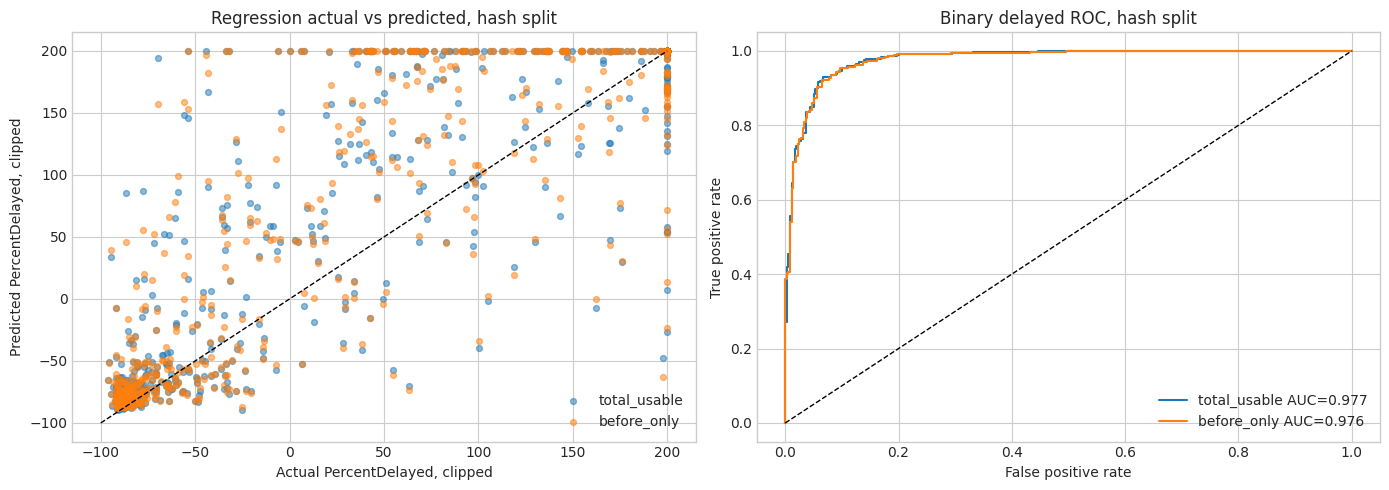

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for feature_set_name, fitted in fitted_hash.items():
    reg, y_true, y_pred, _ = fitted['regression']
    axes[0].scatter(y_true.clip(-100, 200), np.clip(y_pred, -100, 200), alpha=0.5, s=18, label=feature_set_name)
axes[0].plot([-100, 200], [-100, 200], color='black', linestyle='--', linewidth=1)
axes[0].set_title('Regression actual vs predicted, hash split')
axes[0].set_xlabel('Actual PercentDelayed, clipped')
axes[0].set_ylabel('Predicted PercentDelayed, clipped')
axes[0].legend()

for feature_set_name, fitted in fitted_hash.items():
    _, y_true, _, y_prob, _ = fitted['binary']
    if len(np.unique(y_true)) == 2:
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        auc = roc_auc_score(y_true, y_prob)
        axes[1].plot(fpr, tpr, label=f'{feature_set_name} AUC={auc:.3f}')
axes[1].plot([0, 1], [0, 1], color='black', linestyle='--', linewidth=1)
axes[1].set_title('Binary delayed ROC, hash split')
axes[1].set_xlabel('False positive rate')
axes[1].set_ylabel('True positive rate')
axes[1].legend()
plt.tight_layout()
plt.show()

In [10]:
for feature_set_name, fitted in fitted_hash.items():
    print(f'\n=== {feature_set_name}: three-bin confusion matrix, hash split ===')
    _, y_true, y_pred, _ = fitted['three_bin']
    cm = confusion_matrix(y_true, y_pred, labels=[0,1,2])
    cm_df = pd.DataFrame(cm, index=['actual_on_time','actual_mild','actual_mod_sev'], columns=['pred_on_time','pred_mild','pred_mod_sev'])
    display(cm_df)
    print(classification_report(y_true, y_pred, target_names=['before/on time','mildly late','moderate/severe late'], zero_division=0))


=== total_usable: three-bin confusion matrix, hash split ===


,pred_on_time,pred_mild,pred_mod_sev
actual_on_time,314,20,25
actual_mild,2,6,11
actual_mod_sev,17,24,307


                      precision    recall  f1-score   support

      before/on time       0.94      0.87      0.91       359
         mildly late       0.12      0.32      0.17        19
moderate/severe late       0.90      0.88      0.89       348

            accuracy                           0.86       726
           macro avg       0.65      0.69      0.66       726
        weighted avg       0.90      0.86      0.88       726


=== before_only: three-bin confusion matrix, hash split ===


,pred_on_time,pred_mild,pred_mod_sev
actual_on_time,313,26,20
actual_mild,2,6,11
actual_mod_sev,17,24,307


                      precision    recall  f1-score   support

      before/on time       0.94      0.87      0.91       359
         mildly late       0.11      0.32      0.16        19
moderate/severe late       0.91      0.88      0.90       348

            accuracy                           0.86       726
           macro avg       0.65      0.69      0.65       726
        weighted avg       0.90      0.86      0.88       726



## Feature Importance Review

Random forest feature importance is not causal evidence, and correlated keyword columns can split importance across similar features. Still, the top features are useful for sanity checking whether the model is relying on plausible scope/schedule/value signals.

In [11]:
for feature_set_name, feature_cols in feature_sets.items():
    print(f'\n=== Top regression importances: {feature_set_name} ===')
    display(get_feature_importance(fitted_hash[feature_set_name]['regression'][0], feature_cols, top_n=30))
    print(f'\n=== Top binary importances: {feature_set_name} ===')
    display(get_feature_importance(fitted_hash[feature_set_name]['binary'][0], feature_cols, top_n=30))
    print(f'\n=== Top three-bin importances: {feature_set_name} ===')
    display(get_feature_importance(fitted_hash[feature_set_name]['three_bin'][0], feature_cols, top_n=30))


=== Top regression importances: total_usable ===


,Feature,Importance
3325,PLANNEDDURATIONDAYS,0.067354
3322,LOG1PPLANNEDDURATIONDAYS,0.060974
3321,DOLLARSPERPLANNEDMONTH,0.060150
3320,DOLLARSPERPLANNEDDAY,0.059288
3323,MAXCONTRACTPLANNEDDURATIONDAYS,0.054787
3324,MEDIANCONTRACTPLANNEDDURATIONDAYS,0.052743
3315,UNITPRICEMAX,0.029657
3317,UNITPRICEP90,0.025509
3316,UNITPRICEMEDIAN,0.018943
4130,ITEM_KW_TRAINING_PLANNED_VALUE_SHARE,0.017704



=== Top binary importances: total_usable ===


,Feature,Importance
3315,UNITPRICEMAX,0.110456
3321,DOLLARSPERPLANNEDMONTH,0.096528
3320,DOLLARSPERPLANNEDDAY,0.088659
3317,UNITPRICEP90,0.083015
1894,ITEM_KW_MOBILIZATION_ITEM_COUNT,0.053966
1895,ITEM_KW_MOBILIZATION_ITEM_SHARE,0.045754
3316,UNITPRICEMEDIAN,0.043535
3318,UNITPRICESTDDEV,0.041829
2690,MAXITEMPLANNEDVALUE,0.039046
957,DOLLARSPERCONTRACT,0.027418



=== Top three-bin importances: total_usable ===


...

,Feature,Importance
959,DOLLARSPERPLANNEDDAY,0.085233
3559,MEDIANCONTRACTPLANNEDDURATIONDAYS,0.066164
3568,PLANNEDDURATIONDAYS,0.064174
960,DOLLARSPERPLANNEDMONTH,0.062249
3554,LOG1PPLANNEDDURATIONDAYS,0.060491
3555,MAXCONTRACTPLANNEDDURATIONDAYS,0.052138
4185,UNITPRICEMEDIAN,0.023316
4184,UNITPRICEMAX,0.022008
4186,UNITPRICEP90,0.018880
3401,ITEM_KW_TURF_PLANNED_VALUE_SHARE,0.018294



=== Top binary importances: before_only ===


,Feature,Importance
960,DOLLARSPERPLANNEDMONTH,0.123854
959,DOLLARSPERPLANNEDDAY,0.116810
4184,UNITPRICEMAX,0.085361
4186,UNITPRICEP90,0.075776
4185,UNITPRICEMEDIAN,0.064074
2361,ITEM_KW_MOBILIZATION_ITEM_COUNT,0.051563
2362,ITEM_KW_MOBILIZATION_ITEM_SHARE,0.049670
4187,UNITPRICESTDDEV,0.037674
3556,MAXITEMPLANNEDVALUE,0.030952
3560,MEDIANITEMPLANNEDVALUE,0.021123



=== Top three-bin importances: before_only ===


,Feature,Importance
960,DOLLARSPERPLANNEDMONTH,0.062146
959,DOLLARSPERPLANNEDDAY,0.060639
4184,UNITPRICEMAX,0.045222
4186,UNITPRICEP90,0.035997
3556,MAXITEMPLANNEDVALUE,0.035053
957,DOLLARSPERCONTRACT,0.030941
3552,LOG1PABSPROJECTPLANNEDVALUE,0.029481
4187,UNITPRICESTDDEV,0.028213
3573,PROJECTPLANNEDVALUE,0.025857
3554,LOG1PPLANNEDDURATIONDAYS,0.025837


## Time Split Performance

This split is stricter than a random split because test projects are newer than training projects. If performance falls materially, the model may be sensitive to time drift, changes in data entry practices, or changing project mix.

In [12]:
time_results = []
for feature_set_name, feature_cols in feature_sets.items():
    rows, _ = run_one_split(feature_set_name, feature_cols, time_train_idx, time_test_idx, 'time_old_80_new_20', tuned_params=tuned_params)
    time_results.extend(rows)
time_results = pd.DataFrame(time_results)
display(time_results.sort_values(['Task','FeatureSet']))

,MAE,RMSE,BiasMeanPredMinusActual,MedianAbsError,R2,FeatureSet,Split,Task,TrainRows,TestRows,Regularized,Accuracy,BalancedAccuracy,F1,AUC,MacroF1,WeightedF1
4,NaN,NaN,NaN,NaN,NaN,before_only,time_old_80_new_20,binary,2776,693,True,0.834055,0.822081,0.861613,0.914503,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,total_usable,time_old_80_new_20,binary,2776,693,True,0.834055,0.822467,0.861279,0.914020,NaN,NaN
3,116.398589,194.355662,62.242036,81.322573,0.235336,before_only,time_old_80_new_20,regression,2776,693,True,NaN,NaN,NaN,NaN,NaN,NaN
0,117.966253,199.326157,62.979830,83.049851,0.195724,total_usable,time_old_80_new_20,regression,2776,693,True,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,before_only,time_old_80_new_20,three_bin,2776,693,True,0.761905,0.562485,NaN,NaN,0.564135,0.761075
2,NaN,NaN,NaN,NaN,NaN,total_usable,time_old_80_new_20,three_bin,2776,693,True,0.773449,0.563376,NaN,NaN,0.564544,0.762376


## Leave-One-Customer-Out Performance

For each customer, the model trains on all other customers and tests only on the held-out customer. This is a direct check of customer transferability. Small customers can have noisy results, so `TestRows` should be considered when interpreting metrics.

In [13]:
loco_rows = []
customers = sorted(model_df['CUSTOMERNAME'].dropna().unique())
for customer in customers:
    train_idx = model_df.index[model_df['CUSTOMERNAME'] != customer]
    test_idx = model_df.index[model_df['CUSTOMERNAME'] == customer]
    for feature_set_name, feature_cols in feature_sets.items():
        rows, _ = run_one_split(feature_set_name, feature_cols, train_idx, test_idx, f'leave_out_{customer}', tuned_params=tuned_params)
        for row in rows:
            row['HeldOutCustomer'] = customer
            loco_rows.append(row)
loco_results = pd.DataFrame(loco_rows)
display(loco_results.sort_values(['Task','FeatureSet','HeldOutCustomer']))

,MAE,RMSE,BiasMeanPredMinusActual,MedianAbsError,R2,FeatureSet,Split,Task,TrainRows,TestRows,Regularized,HeldOutCustomer,Accuracy,BalancedAccuracy,F1,AUC,MacroF1,WeightedF1
4,NaN,NaN,NaN,NaN,NaN,before_only,leave_out_Adams,binary,3392,77,True,Adams,0.740260,0.663704,0.821429,0.715556,NaN,NaN
10,NaN,NaN,NaN,NaN,NaN,before_only,leave_out_CCD,binary,3277,192,True,CCD,0.671875,0.638924,0.479339,0.694479,NaN,NaN
16,NaN,NaN,NaN,NaN,NaN,before_only,leave_out_CLV,binary,3467,2,True,CLV,0.500000,0.500000,0.000000,NaN,NaN,NaN
22,NaN,NaN,NaN,NaN,NaN,before_only,leave_out_Lincoln,binary,1648,1821,True,Lincoln,0.876991,0.744132,0.647799,0.910632,NaN,NaN
28,NaN,NaN,NaN,NaN,NaN,before_only,leave_out_UDOT,binary,2092,1377,True,UDOT,0.947712,0.630210,0.972727,0.803447,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,total_usable,leave_out_Adams,binary,3392,77,True,Adams,0.714286,0.626667,0.807018,0.719259,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,total_usable,leave_out_CCD,binary,3277,192,True,CCD,0.671875,0.651439,0.496000,0.706856,NaN,NaN
13,NaN,NaN,NaN,NaN,NaN,total_usable,leave_out_CLV,binary,3467,2,True,CLV,0.500000,0.500000,0.000000,NaN,NaN,NaN
19,NaN,NaN,NaN,NaN,NaN,total_usable,leave_out_Lincoln,binary,1648,1821,True,Lincoln,0.881384,0.756484,0.667692,0.906741,NaN,NaN
25,NaN,NaN,NaN,NaN,NaN,total_usable,leave_out_UDOT,binary,2092,1377,True,UDOT,0.947712,0.617992,0.972769,0.815519,NaN,NaN


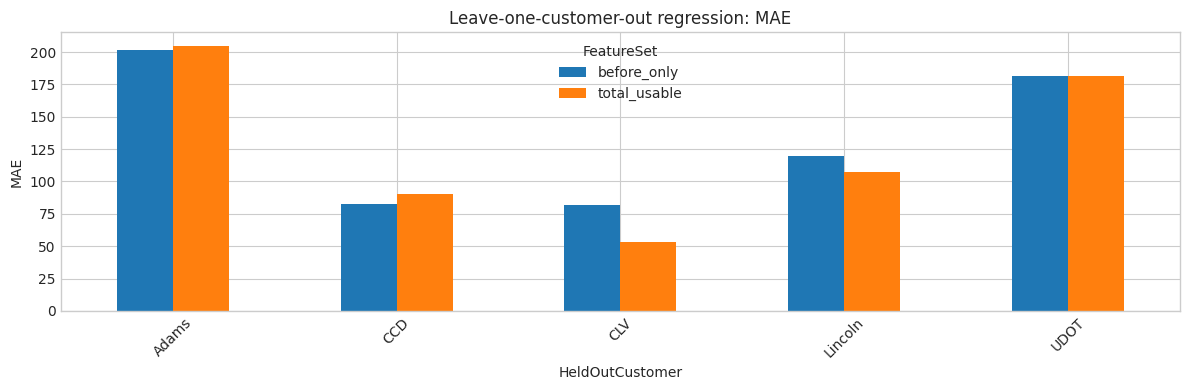

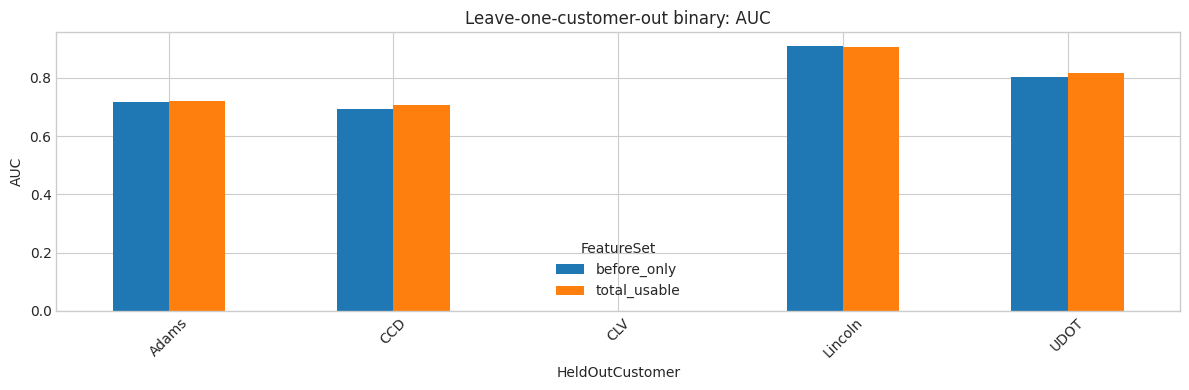

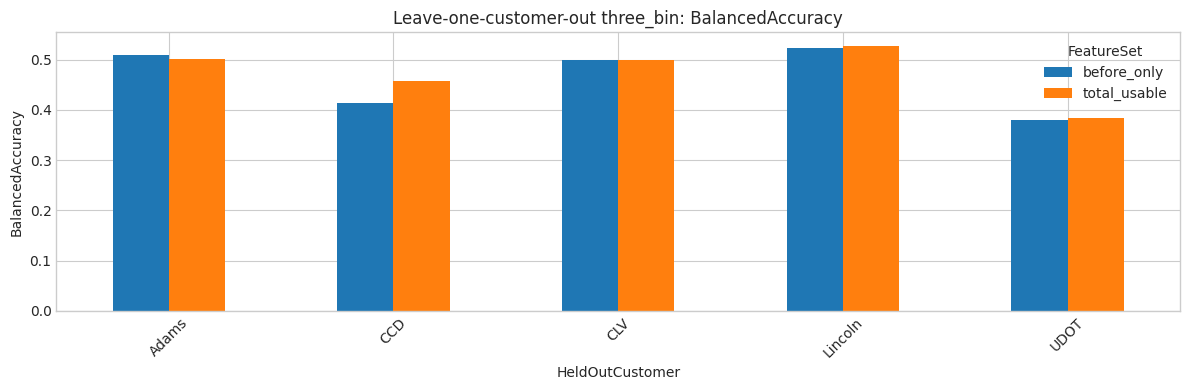

In [14]:
for task, metric in [('regression','MAE'), ('binary','AUC'), ('three_bin','BalancedAccuracy')]:
    sub = loco_results[loco_results['Task'].eq(task)].copy()
    if sub.empty or metric not in sub.columns:
        continue
    pivot = sub.pivot(index='HeldOutCustomer', columns='FeatureSet', values=metric)
    ax = pivot.plot(kind='bar', figsize=(12,4), rot=45)
    ax.set_title(f'Leave-one-customer-out {task}: {metric}')
    ax.set_ylabel(metric)
    plt.tight_layout()
    plt.show()

## Conservative UDOT Old-Only Training Stress Test

This test trains on only the oldest 80% of labeled UDOT projects. It then evaluates on newer UDOT projects and each non-UDOT customer. This is intentionally difficult: it tests temporal generalization inside UDOT and cross-customer transfer from one customer's historical data.

In [15]:
udot_stress_rows = []
udot_eval_sets = {'UDOT_newer_20pct': udot_new_test_idx}
for customer in sorted(model_df.loc[model_df['CUSTOMERNAME'] != 'UDOT', 'CUSTOMERNAME'].dropna().unique()):
    udot_eval_sets[f'{customer}_all'] = model_df.index[model_df['CUSTOMERNAME'] == customer]

for eval_name, test_idx in udot_eval_sets.items():
    for feature_set_name, feature_cols in feature_sets.items():
        rows, _ = run_one_split(feature_set_name, feature_cols, udot_old_train_idx, test_idx, f'udot_old80_train__{eval_name}', tuned_params=tuned_params)
        for row in rows:
            row['EvalSet'] = eval_name
            udot_stress_rows.append(row)
udot_stress_results = pd.DataFrame(udot_stress_rows)
display(udot_stress_results.sort_values(['Task','FeatureSet','EvalSet']))

,MAE,RMSE,BiasMeanPredMinusActual,MedianAbsError,R2,FeatureSet,Split,Task,TrainRows,TestRows,Regularized,EvalSet,Accuracy,BalancedAccuracy,F1,AUC,MacroF1,WeightedF1
10,NaN,NaN,NaN,NaN,NaN,before_only,udot_old80_train__Adams_all,binary,1104,77,True,Adams_all,0.649351,0.542593,0.769231,0.737037,NaN,NaN
16,NaN,NaN,NaN,NaN,NaN,before_only,udot_old80_train__CCD_all,binary,1104,192,True,CCD_all,0.692708,0.590530,0.391753,0.645946,NaN,NaN
22,NaN,NaN,NaN,NaN,NaN,before_only,udot_old80_train__CLV_all,binary,1104,2,True,CLV_all,1.000000,1.000000,0.000000,NaN,NaN,NaN
28,NaN,NaN,NaN,NaN,NaN,before_only,udot_old80_train__Lincoln_all,binary,1104,1821,True,Lincoln_all,0.903899,0.831573,0.766355,0.913319,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,before_only,udot_old80_train__UDOT_newer_20pct,binary,1104,273,True,UDOT_newer_20pct,0.820513,0.500000,0.901408,0.774827,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,total_usable,udot_old80_train__Adams_all,binary,1104,77,True,Adams_all,0.675325,0.562593,0.789916,0.736296,NaN,NaN
13,NaN,NaN,NaN,NaN,NaN,total_usable,udot_old80_train__CCD_all,binary,1104,192,True,CCD_all,0.734375,0.643930,0.474227,0.683493,NaN,NaN
19,NaN,NaN,NaN,NaN,NaN,total_usable,udot_old80_train__CLV_all,binary,1104,2,True,CLV_all,1.000000,1.000000,0.000000,NaN,NaN,NaN
25,NaN,NaN,NaN,NaN,NaN,total_usable,udot_old80_train__Lincoln_all,binary,1104,1821,True,Lincoln_all,0.904448,0.839714,0.772846,0.905013,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,total_usable,udot_old80_train__UDOT_newer_20pct,binary,1104,273,True,UDOT_newer_20pct,0.820513,0.500000,0.901408,0.769224,NaN,NaN


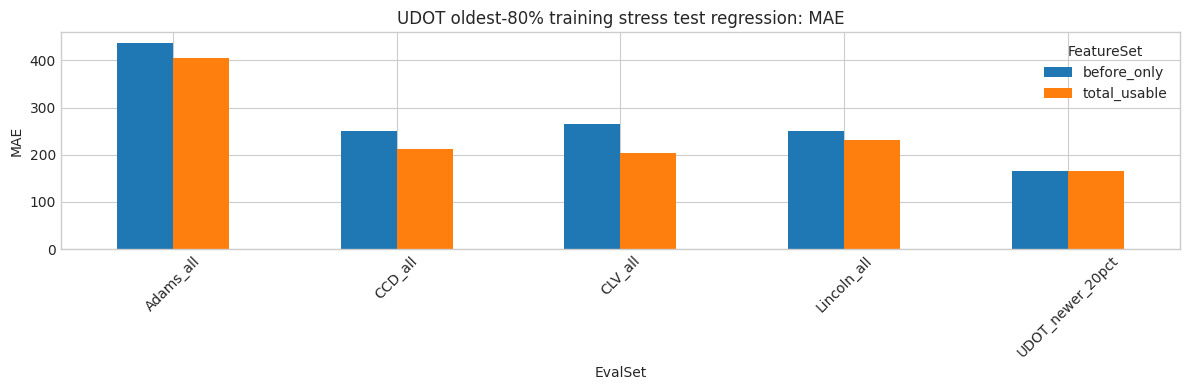

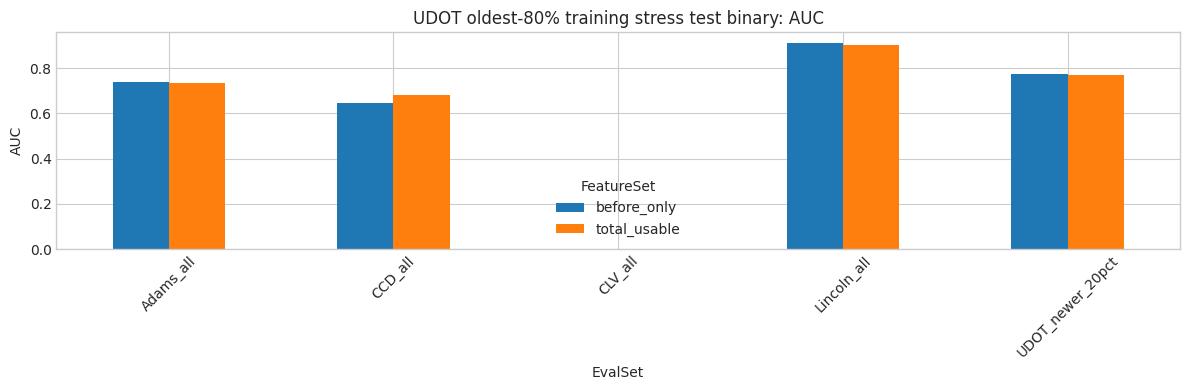

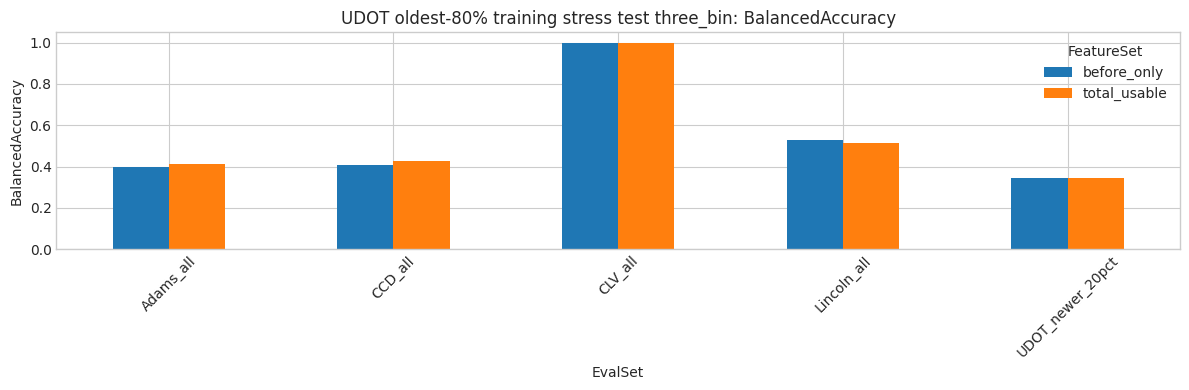

In [16]:
for task, metric in [('regression','MAE'), ('binary','AUC'), ('three_bin','BalancedAccuracy')]:
    sub = udot_stress_results[udot_stress_results['Task'].eq(task)].copy()
    if sub.empty or metric not in sub.columns:
        continue
    pivot = sub.pivot(index='EvalSet', columns='FeatureSet', values=metric)
    ax = pivot.plot(kind='bar', figsize=(12,4), rot=45)
    ax.set_title(f'UDOT oldest-80% training stress test {task}: {metric}')
    ax.set_ylabel(metric)
    plt.tight_layout()
    plt.show()

## Consolidated Model Comparison

The model comparison is split by task so every displayed metric is meaningful. A single wide table across regression, binary classification, and three-bin classification creates structural missing values: regression has MAE/RMSE/R2, binary classification has AUC/F1/balanced accuracy, and three-bin classification has multiclass accuracy/F1 metrics.

The tables below therefore compare:

- Regression using `MAE`, `RMSE`, bias, and `R2`.
- Binary delayed/not-delayed classification using `AUC`, balanced accuracy, F1, and accuracy.
- Three-bin severity classification using balanced accuracy, macro F1, weighted F1, and accuracy.

Lower is better for `MAE`, `RMSE`, and absolute bias. Higher is better for `R2`, `AUC`, balanced accuracy, and F1 metrics.

In [17]:

combined_results = pd.concat([
    hash_results.assign(SplitFamily='hash'),
    time_results.assign(SplitFamily='time'),
    loco_results.assign(SplitFamily='leave_one_customer_out'),
    udot_stress_results.assign(SplitFamily='udot_old_only'),
], ignore_index=True, sort=False)

combined_results.to_csv('project_delay_rf_approved_keywords_model_results_2026-06-11.csv', index=False)

def tidy_metric_table(task, metric_cols):
    id_cols = ['SplitFamily', 'Split', 'FeatureSet', 'TrainRows', 'TestRows']
    optional_cols = ['HeldOutCustomer', 'EvalSet']
    cols = id_cols + [c for c in optional_cols if c in combined_results.columns] + metric_cols
    cols = [c for c in cols if c in combined_results.columns]
    out = combined_results.loc[combined_results['Task'].eq(task), cols].copy()
    for c in metric_cols:
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors='coerce')
    return out.sort_values(['SplitFamily', 'Split', 'FeatureSet']).reset_index(drop=True)

regression_comparison = tidy_metric_table(
    'regression',
    ['MAE', 'RMSE', 'BiasMeanPredMinusActual', 'MedianAbsError', 'R2']
)
binary_comparison = tidy_metric_table(
    'binary',
    ['AUC', 'BalancedAccuracy', 'F1', 'Accuracy']
)
three_bin_comparison = tidy_metric_table(
    'three_bin',
    ['BalancedAccuracy', 'MacroF1', 'WeightedF1', 'Accuracy']
)


def display_clean_table(table, metric_cols):
    out = table.copy()
    for c in ['HeldOutCustomer', 'EvalSet']:
        if c in out.columns:
            out[c] = out[c].fillna('')
    for c in metric_cols:
        if c in out.columns:
            out[c] = out[c].map(lambda x: 'not defined' if pd.isna(x) else f'{x:.3f}')
    display(out)

print('Regression comparison: actual numbers only for regression metrics')
display_clean_table(regression_comparison, ['MAE', 'RMSE', 'BiasMeanPredMinusActual', 'MedianAbsError', 'R2'])
print('Binary delayed/not-delayed comparison: actual numbers only for binary metrics')
display_clean_table(binary_comparison, ['AUC', 'BalancedAccuracy', 'F1', 'Accuracy'])
print('Three-bin delay severity comparison: actual numbers only for multiclass metrics')
display_clean_table(three_bin_comparison, ['BalancedAccuracy', 'MacroF1', 'WeightedF1', 'Accuracy'])

undefined_auc_rows = binary_comparison[binary_comparison['AUC'].isna()].copy()
if len(undefined_auc_rows):
    print('Note: binary AUC is marked not defined where the test fold contains only one observed class. This most often happens in very small held-out customer folds.')
    display(undefined_auc_rows[['SplitFamily', 'Split', 'FeatureSet', 'TestRows', 'HeldOutCustomer', 'EvalSet']].fillna(''))


# Build concise aggregate summaries by split family and feature set.
reg_summary = regression_comparison.groupby(['SplitFamily', 'FeatureSet'], dropna=False).agg(
    Tests=('Split', 'count'),
    MeanMAE=('MAE', 'mean'),
    MedianMAE=('MAE', 'median'),
    MeanRMSE=('RMSE', 'mean'),
    MeanBias=('BiasMeanPredMinusActual', 'mean'),
    MeanR2=('R2', 'mean'),
).reset_index()

bin_summary = binary_comparison.groupby(['SplitFamily', 'FeatureSet'], dropna=False).agg(
    Tests=('Split', 'count'),
    MeanAUC=('AUC', 'mean'),
    MedianAUC=('AUC', 'median'),
    MeanBalancedAccuracy=('BalancedAccuracy', 'mean'),
    MeanF1=('F1', 'mean'),
).reset_index()

multi_summary = three_bin_comparison.groupby(['SplitFamily', 'FeatureSet'], dropna=False).agg(
    Tests=('Split', 'count'),
    MeanBalancedAccuracy=('BalancedAccuracy', 'mean'),
    MedianBalancedAccuracy=('BalancedAccuracy', 'median'),
    MeanMacroF1=('MacroF1', 'mean'),
    MeanWeightedF1=('WeightedF1', 'mean'),
).reset_index()

print('Regression summary by split family and feature set')
display(reg_summary)
print('Binary summary by split family and feature set')
display(bin_summary)
print('Three-bin summary by split family and feature set')
display(multi_summary)

# Focused headline table for the ordinary hash split and time split.
headline_rows = []
for split_family, split_label in [('hash', 'Hash 80/20'), ('time', 'Time old 80/new 20')]:
    for fs in ['total_usable', 'before_only']:
        reg = regression_comparison[(regression_comparison.SplitFamily == split_family) & (regression_comparison.FeatureSet == fs)]
        binary = binary_comparison[(binary_comparison.SplitFamily == split_family) & (binary_comparison.FeatureSet == fs)]
        multi = three_bin_comparison[(three_bin_comparison.SplitFamily == split_family) & (three_bin_comparison.FeatureSet == fs)]
        if len(reg) and len(binary) and len(multi):
            headline_rows.append({
                'Split': split_label,
                'FeatureSet': fs,
                'Regression_MAE': float(reg['MAE'].iloc[0]),
                'Regression_RMSE': float(reg['RMSE'].iloc[0]),
                'Regression_R2': float(reg['R2'].iloc[0]),
                'Binary_AUC': float(binary['AUC'].iloc[0]),
                'Binary_BalancedAccuracy': float(binary['BalancedAccuracy'].iloc[0]),
                'ThreeBin_BalancedAccuracy': float(multi['BalancedAccuracy'].iloc[0]),
                'ThreeBin_MacroF1': float(multi['MacroF1'].iloc[0]),
            })
headline = pd.DataFrame(headline_rows)
print('Headline comparison for primary splits')
display(headline)

# Generated takeaways.
def metric_lookup(df_, split_family, feature_set, metric):
    rows = df_[(df_.SplitFamily == split_family) & (df_.FeatureSet == feature_set)]
    if rows.empty or metric not in rows.columns:
        return np.nan
    return float(rows[metric].iloc[0])

takeaways = []
for fs in ['total_usable', 'before_only']:
    hash_mae = metric_lookup(regression_comparison, 'hash', fs, 'MAE')
    time_mae = metric_lookup(regression_comparison, 'time', fs, 'MAE')
    hash_auc = metric_lookup(binary_comparison, 'hash', fs, 'AUC')
    time_auc = metric_lookup(binary_comparison, 'time', fs, 'AUC')
    hash_multi = metric_lookup(three_bin_comparison, 'hash', fs, 'BalancedAccuracy')
    time_multi = metric_lookup(three_bin_comparison, 'time', fs, 'BalancedAccuracy')
    takeaways.append(
        f"{fs}: regression MAE moves from {hash_mae:.1f} on the hash split to {time_mae:.1f} on the time split; "
        f"binary AUC moves from {hash_auc:.3f} to {time_auc:.3f}; three-bin balanced accuracy moves from {hash_multi:.3f} to {time_multi:.3f}."
    )

# Compare total vs before-only on primary splits.
for split_family, label in [('hash', 'hash split'), ('time', 'time split')]:
    total_auc = metric_lookup(binary_comparison, split_family, 'total_usable', 'AUC')
    before_auc = metric_lookup(binary_comparison, split_family, 'before_only', 'AUC')
    total_mae = metric_lookup(regression_comparison, split_family, 'total_usable', 'MAE')
    before_mae = metric_lookup(regression_comparison, split_family, 'before_only', 'MAE')
    takeaways.append(
        f"On the {label}, before-only features are very close to total-usable features: "
        f"binary AUC difference is {before_auc - total_auc:+.3f} and regression MAE difference is {before_mae - total_mae:+.1f}."
    )

# Leave-one-customer-out and UDOT stress summaries.
for fs in ['total_usable', 'before_only']:
    loco_bin = bin_summary[(bin_summary.SplitFamily == 'leave_one_customer_out') & (bin_summary.FeatureSet == fs)]
    loco_reg = reg_summary[(reg_summary.SplitFamily == 'leave_one_customer_out') & (reg_summary.FeatureSet == fs)]
    udot_bin = bin_summary[(bin_summary.SplitFamily == 'udot_old_only') & (bin_summary.FeatureSet == fs)]
    udot_reg = reg_summary[(reg_summary.SplitFamily == 'udot_old_only') & (reg_summary.FeatureSet == fs)]
    if len(loco_bin) and len(loco_reg):
        takeaways.append(
            f"{fs}: leave-one-customer-out average binary AUC is {float(loco_bin.MeanAUC.iloc[0]):.3f} "
            f"with average regression MAE {float(loco_reg.MeanMAE.iloc[0]):.1f}; this is the best customer-transferability summary."
        )
    if len(udot_bin) and len(udot_reg):
        takeaways.append(
            f"{fs}: UDOT-old-only stress average binary AUC is {float(udot_bin.MeanAUC.iloc[0]):.3f} "
            f"with average regression MAE {float(udot_reg.MeanMAE.iloc[0]):.1f}; this is intentionally conservative and should be treated as a lower-bound generalization check."
        )

print('Generated takeaways')
for t in takeaways:
    print(f'- {t}')

# Persist clearer comparison artifacts.
regression_comparison.to_csv('project_delay_rf_approved_keywords_regression_comparison_2026-06-11.csv', index=False)
binary_comparison.to_csv('project_delay_rf_approved_keywords_binary_comparison_2026-06-11.csv', index=False)
three_bin_comparison.to_csv('project_delay_rf_approved_keywords_three_bin_comparison_2026-06-11.csv', index=False)
headline.to_csv('project_delay_rf_approved_keywords_headline_comparison_2026-06-11.csv', index=False)
print('Saved task-specific comparison CSVs.')


Regression comparison: actual numbers only for regression metrics


,SplitFamily,Split,FeatureSet,TrainRows,TestRows,HeldOutCustomer,EvalSet,MAE,RMSE,BiasMeanPredMinusActual,MedianAbsError,R2
0,hash,hash_80_20,before_only,2743,726,,,109.951,276.485,-7.551,36.369,0.416
1,hash,hash_80_20,total_usable,2743,726,,,109.729,276.745,-8.322,37.268,0.415
2,leave_one_customer_out,leave_out_Adams,before_only,3392,77,Adams,,201.792,359.967,25.958,111.645,0.341
3,leave_one_customer_out,leave_out_Adams,total_usable,3392,77,Adams,,204.950,362.986,24.408,105.778,0.330
4,leave_one_customer_out,leave_out_CCD,before_only,3277,192,CCD,,82.832,112.128,48.092,72.167,-0.203
5,leave_one_customer_out,leave_out_CCD,total_usable,3277,192,CCD,,89.955,116.804,58.788,78.075,-0.305
6,leave_one_customer_out,leave_out_CLV,before_only,3467,2,CLV,,81.728,81.761,81.728,81.728,-13.956
7,leave_one_customer_out,leave_out_CLV,total_usable,3467,2,CLV,,53.271,53.274,53.271,53.271,-5.350
8,leave_one_customer_out,leave_out_Lincoln,before_only,1648,1821,Lincoln,,119.724,193.206,68.608,106.660,0.357
9,leave_one_customer_out,leave_out_Lincoln,total_usable,1648,1821,Lincoln,,107.267,187.256,54.160,91.210,0.396


Binary delayed/not-delayed comparison: actual numbers only for binary metrics


,SplitFamily,Split,FeatureSet,TrainRows,TestRows,HeldOutCustomer,EvalSet,AUC,BalancedAccuracy,F1,Accuracy
0,hash,hash_80_20,before_only,2743,726,,,0.976,0.923,0.925,0.923
1,hash,hash_80_20,total_usable,2743,726,,,0.977,0.925,0.928,0.926
2,leave_one_customer_out,leave_out_Adams,before_only,3392,77,Adams,,0.716,0.664,0.821,0.740
3,leave_one_customer_out,leave_out_Adams,total_usable,3392,77,Adams,,0.719,0.627,0.807,0.714
4,leave_one_customer_out,leave_out_CCD,before_only,3277,192,CCD,,0.694,0.639,0.479,0.672
5,leave_one_customer_out,leave_out_CCD,total_usable,3277,192,CCD,,0.707,0.651,0.496,0.672
6,leave_one_customer_out,leave_out_CLV,before_only,3467,2,CLV,,not defined,0.500,0.000,0.500
7,leave_one_customer_out,leave_out_CLV,total_usable,3467,2,CLV,,not defined,0.500,0.000,0.500
8,leave_one_customer_out,leave_out_Lincoln,before_only,1648,1821,Lincoln,,0.911,0.744,0.648,0.877
9,leave_one_customer_out,leave_out_Lincoln,total_usable,1648,1821,Lincoln,,0.907,0.756,0.668,0.881


Three-bin delay severity comparison: actual numbers only for multiclass metrics


...

Three-bin summary by split family and feature set


,SplitFamily,FeatureSet,Tests,MeanBalancedAccuracy,MedianBalancedAccuracy,MeanMacroF1,MeanWeightedF1
0,hash,before_only,1,0.689947,0.689947,0.653659,0.881192
1,hash,total_usable,1,0.690875,0.690875,0.656665,0.879233
2,leave_one_customer_out,before_only,5,0.465527,0.500000,0.365366,0.600385
3,leave_one_customer_out,total_usable,5,0.474589,0.500000,0.396096,0.655961
4,time,before_only,1,0.562485,0.562485,0.564135,0.761075
5,time,total_usable,1,0.563376,0.563376,0.564544,0.762376
6,udot_old_only,before_only,5,0.535184,0.405368,0.533347,0.757009
7,udot_old_only,total_usable,5,0.539341,0.427340,0.540028,0.761913


Headline comparison for primary splits


,Split,FeatureSet,Regression_MAE,Regression_RMSE,Regression_R2,Binary_AUC,Binary_BalancedAccuracy,ThreeBin_BalancedAccuracy,ThreeBin_MacroF1
0,Hash 80/20,total_usable,109.729268,276.744729,0.414720,0.977207,0.925429,0.690875,0.656665
1,Hash 80/20,before_only,109.950571,276.485099,0.415817,0.976357,0.922643,0.689947,0.653659
2,Time old 80/new 20,total_usable,117.966253,199.326157,0.195724,0.914020,0.822467,0.563376,0.564544
3,Time old 80/new 20,before_only,116.398589,194.355662,0.235336,0.914503,0.822081,0.562485,0.564135


Generated takeaways
- total_usable: regression MAE moves from 109.7 on the hash split to 118.0 on the time split; binary AUC moves from 0.977 to 0.914; three-bin balanced accuracy moves from 0.691 to 0.563.
- before_only: regression MAE moves from 110.0 on the hash split to 116.4 on the time split; binary AUC moves from 0.976 to 0.915; three-bin balanced accuracy moves from 0.690 to 0.562.
- On the hash split, before-only features are very close to total-usable features: binary AUC difference is -0.001 and regression MAE difference is +0.2.
- On the time split, before-only features are very close to total-usable features: binary AUC difference is +0.000 and regression MAE difference is -1.6.
- total_usable: leave-one-customer-out average binary AUC is 0.787 with average regression MAE 127.3; this is the best customer-transferability summary.
- total_usable: UDOT-old-only stress average binary AUC is 0.774 with average regression MAE 244.2; this is intentionally conservative and should 

In [18]:
# Save machine-readable outputs for follow-up review.
combined_results.to_csv('project_delay_rf_approved_keywords_model_results_2026-06-11.csv', index=False)
for feature_set_name, feature_cols in feature_sets.items():
    for task_name in ['regression', 'binary', 'three_bin']:
        imp = get_feature_importance(fitted_hash[feature_set_name][task_name][0], feature_cols, top_n=100)
        imp.to_csv(f'project_delay_rf_approved_keywords_{feature_set_name}_{task_name}_top_importances_2026-06-11.csv', index=False)
print('Saved model result and top-importance CSV files.')

Saved model result and top-importance CSV files.


## Interpretation Checklist

When reviewing the outputs, prioritize the split strategy hierarchy:

1. Hash split indicates whether the restricted feature set can fit historical labeled data at all.
2. Time split indicates whether the model is stable when future projects differ from older projects.
3. Leave-one-customer-out indicates whether signals transfer across customers without using customer name as a predictor.
4. UDOT-old-only training is the most conservative stress test and should be treated as a lower-bound view of generalization from a narrow historical base.

The most deployable model is not necessarily the model with the best hash split score. A model that is slightly weaker on the hash split but materially more stable by time and customer is more credible for production use.